In [20]:
import os
import sys
import yaml
import torch

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import DataLoader
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from omegaconf import OmegaConf
from PIL import Image


# set directory to parent directory
os.chdir("/Users/jorgegoncalves/Desktop/Repositories/Master_Thesis/treevae")

# print current working directory
print("Current Working Directory:", os.getcwd())

from utils.data_utils import get_data, get_gen
from utils.data_utils import get_data, get_gen
from utils.model_utils import construct_tree_fromnpy
from utils.utils import reset_random_seeds, prepare_config, display_image
from models.model import TreeVAE

Current Working Directory: /Users/jorgegoncalves/Desktop/Repositories/Master_Thesis/treevae


In [21]:
from utils.plotting_utils import plot_tree_graph

path = '/Users/jorgegoncalves/Desktop/Repositories/Master_Thesis/treevae/models/experiments/'

dataset = 'mnist'
ex_name = '/20240308-131511_3da26'

dataset = 'fmnist'
ex_name = '/20240301-204616_da161'

dataset = 'cifar10'
ex_name = '/20240307-195731_9e95e'

checkpoint_path = path+dataset+ex_name

with open(checkpoint_path + "/config.yaml", 'r') as stream:
    configs = yaml.load(stream,Loader=yaml.Loader)
print(configs)

{'data': {'data_name': 'cifar10', 'num_clusters_data': 10}, 'ddpm': {'data': {'data_name': 'cifar10', 'ddpm_latent_path': '', 'image_size': 32, 'inp_channels': 3, 'norm': True, 'num_clusters_data': 10}, 'evaluation': {'chkpt_path': '/cluster/work/vogtlab/Group/jogoncalves/results/cifar10/checkpoints/ddpmv2-vae-epoch=934-loss=0.0109.ckpt', 'eval_mode': 'sample_all_leaves', 'guidance_weight': 0.0, 'n_samples': 10000, 'n_steps': 1000, 'resample_strategy': 'truncated', 'sample_from': 'target', 'sample_method': 'ddpm', 'sample_prefix': '', 'save_mode': 'image', 'save_path': '/cluster/work/vogtlab/Group/jogoncalves/results/cifar10/', 'save_vae': True, 'skip_strategy': 'quad', 'temp': 1.0, 'type': 'form1', 'variance': 'fixedlarge', 'z_cond': True, 'z_dim': 1}, 'globals': {'seed': 42}, 'model': {'attn_resolutions': '16,', 'beta1': 0.0001, 'beta2': 0.02, 'dim': 64, 'dim_mults': '1,2,2,2', 'dropout': 0.3, 'n_heads': 8, 'n_residual': 2, 'n_timesteps': 1000}, 'training': {'batch_size': 256, 'cfd_r

In [22]:
trainset, trainset_eval, testset = get_data(configs)
gen_train = get_gen(trainset, configs, validation=False, shuffle=False)
gen_train_eval = get_gen(trainset_eval, configs, validation=True, shuffle=False)
gen_test = get_gen(testset, configs, validation=True, shuffle=False)

y_train = trainset_eval.dataset.targets.clone().detach()[trainset_eval.indices].numpy()
y_test = testset.dataset.targets.clone().detach()[testset.indices].numpy()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TreeVAE(**configs['training'])
data_tree = np.load(checkpoint_path+'/data_tree.npy', allow_pickle=True)

model = construct_tree_fromnpy(model, data_tree, configs)
if not (configs['globals']['eager_mode'] and configs['globals']['wandb_logging']!='offline'):
    #model = torch.compile(model)
    pass
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.load_state_dict(torch.load(checkpoint_path+'/model_weights.pt', map_location=device), strict=True)
model.to(device)
model.eval()

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


TreeVAE(
  (bottom_up): ModuleList(
    (0): Resnet_Encoder(
      (conv_img): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (resnet): Sequential(
        (0): ResnetBlock(
          (conv_0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (conv_1): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (conv_2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (bn0): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (bn2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): AvgPool2d(kernel_size=3, stride=2, padding=1)
        (2): ResnetBlock(
          (conv_0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (conv_1): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


KeyboardInterrupt: 

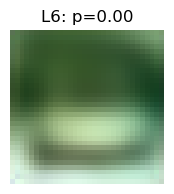

In [24]:
# get test set reconstructions

# setup dirs
vae_save_path = f"../results_all_leaves/{dataset}/seed_1/vae"
img_save_path = os.path.join(vae_save_path, "recons_all_leaves")


# loop over gen_test
for j, (x, y) in enumerate(gen_test):
    x = x.to(device)
    y = y.to(device)

    with torch.no_grad():
        res = model.compute_reconstruction(x)
        recons = res[0]
        nodes = res[1]

        num_leaves = len(nodes)

        # loop over each class and save every TreeVAE reconstruction of this class separately
        for c in range(num_leaves):
            # Setup a dir for each class
            class_save_pass = os.path.join(img_save_path, f"img_cluster_{c}")
            os.makedirs(class_save_pass, exist_ok=True)
            # save every image of this class separately
            for i in range(x.shape[0]):
                prob = nodes[c]['prob'][i].cpu()
                fig, axs = plt.subplots(1, 1, figsize=(2, 2))
                axs.imshow(display_image(recons[c][i]), cmap=plt.get_cmap('gray'))
                axs.set_title(f"L{c}: " + f"p=%.2f" % torch.round(prob, decimals=2))
                axs.axis('off')
                # save image
                plt.savefig(os.path.join(class_save_pass, f"output__{0}_{j}_{i}_{prob}.png"))
                plt.close()
        




In [ ]:
# get new generations

# setup dirs
vae_save_path = '../results_all_leaves/cifar10/vae'
img_save_path = os.path.join(vae_save_path, "sample_all_leaves")

# loop over gen_test --> not really used, only to get again 10k
for j, (x, y) in enumerate(gen_test):
    n_samples = x[0].size(0)
    reconstructions, p_c_z = model.generate_images(n_samples, x[0].device)

    num_leaves = len(reconstructions)

    # loop over each class and save every TreeVAE reconstruction of this class separately
    for c in range(num_leaves):
        # Setup a dir for each class
        class_save_pass = os.path.join(img_save_path, f"img_cluster_{c}")
        os.makedirs(class_save_pass, exist_ok=True)
        # save every image of this class separately
        for i in range(n_samples):
            prob = p_c_z[c][i].cpu().numpy()
            fig, axs = plt.subplots(1, 1, figsize=(2, 2))
            axs.imshow(display_image(reconstructions[c][i]), cmap=plt.get_cmap('gray'))
            axs.set_title(f"L{c}: " + f"p=%.2f" % torch.round(prob, decimals=2))
            axs.axis('off')
            # save image
            plt.savefig(os.path.join(class_save_pass, f"output__{0}_{j}_{i}_{prob}.png"))
            plt.close()